# E4b — Content patching at \(t^*\)

**Extension of E4.** E4 patched the **source** (`W_window`). E4b patches the **probe** (`t*`)
residual across depth: when is W preference decided **locally at \(t^***\), vs inherited from `W`?

Same W/C counterfactual runs. Primary readout: \(\mathrm{logit}(W)-\mathrm{logit}(C)\) at \(t^*\).


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))
import json, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
import transformer_lens as tl
from IPython.display import display, Image
from E4_content_patching import ITEMS
from E4b_content_patching_tstar import (
    OUT_DIR, run_item_interventions, aggregate_results,
    plot_tstar_layer_sweep, plot_band_bars, plot_comparison_sweep,
)
torch.set_grad_enabled(False)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)


device: cpu


In [2]:
model = tl.HookedTransformer.from_pretrained('gpt2', device=DEVICE, fold_ln=False)
model.eval()
all_results = []
for item in ITEMS:
    all_results.extend(run_item_interventions(model, item))
df = aggregate_results(all_results)
OUT_DIR.mkdir(exist_ok=True)
df.to_csv(OUT_DIR / 'all_interventions.csv', index=False)
summary = df.groupby('intervention').agg(
    mean_baseline=('baseline','mean'), mean_patched=('patched','mean'),
    mean_delta=('delta','mean'), sem_delta=('delta','sem'), n=('delta','count')
).reset_index().sort_values('mean_delta')
display(summary[summary['intervention'].str.contains('tstar|ref_E4')])


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer


,intervention,mean_baseline,mean_patched,mean_delta,sem_delta,n
2,necessity_resid_tstar_L0-11_Cswap,2.707782,-2.681088,-5.388870,0.541462,8
17,necessity_resid_tstar_L9-11_Cswap,2.707782,-2.681088,-5.388870,0.541462,8
6,necessity_resid_tstar_L11_Cswap,2.707782,-2.681088,-5.388870,0.541462,8
11,necessity_resid_tstar_L5-11_Cswap,2.707782,-2.681088,-5.388870,0.541462,8
5,necessity_resid_tstar_L10_Cswap,2.707782,-2.597421,-5.305203,0.533550,8
18,necessity_resid_tstar_L9_Cswap,2.707782,-2.575390,-5.283172,0.478753,8
19,ref_E4_necessity_Wwin_L5-11_Cswap,2.707782,-2.229697,-4.937479,0.526704,8
16,necessity_resid_tstar_L8_Cswap,2.707782,-0.343725,-3.051507,0.329163,8
12,necessity_resid_tstar_L5-8_Cswap,2.707782,-0.343725,-3.051507,0.329163,8
15,necessity_resid_tstar_L7_Cswap,2.707782,-0.019821,-2.727603,0.287357,8


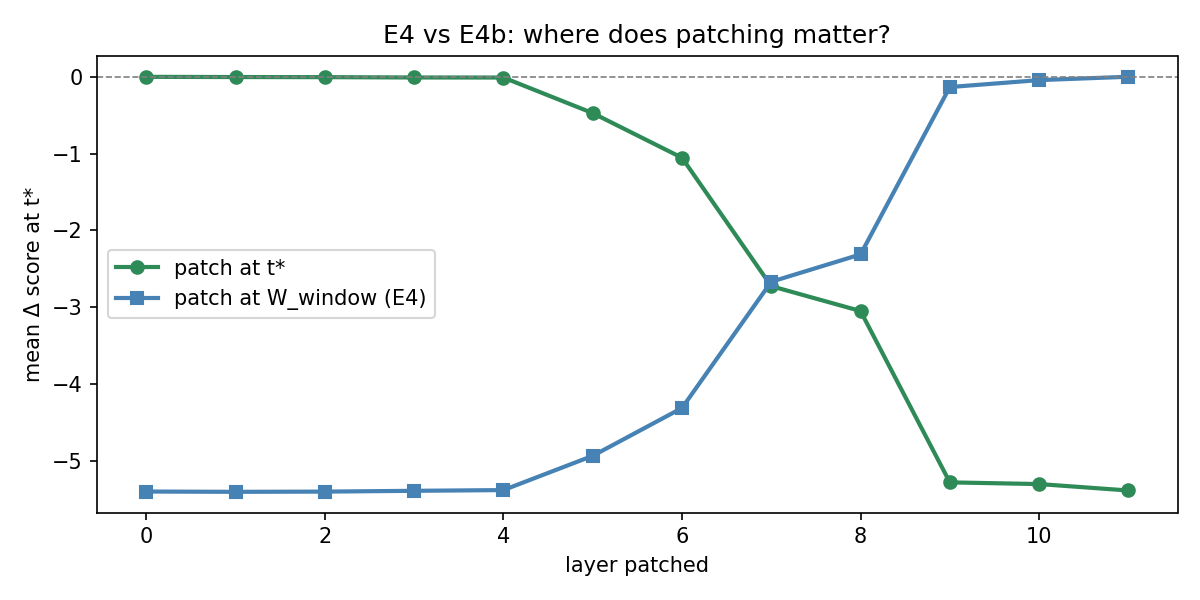

In [3]:
plot_tstar_layer_sweep(df, 'per_layer_tstar_necessity.png')
plot_band_bars(summary, 'band_interventions.png')
e4_df = pd.read_csv('E4_outputs/all_interventions.csv')
plot_comparison_sweep(df, e4_df, 'e4_vs_e4b_layer_sweep.png')
Image(filename=OUT_DIR / 'e4_vs_e4b_layer_sweep.png')
